<a href="https://colab.research.google.com/github/JuanAndrewD/RMCT_Assignment_Codebase/blob/main/FVG_RMCT_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Algorithmic Validation of Retail Price Action: Fair Value Gap (FVG) Module**

This notebook contains the implementation and empirical validation of a popular Retail Trading Strategy: the Fair Value Gap (FVG).

The primary goal of this specific module is to address the Subjectivity Gap in retail trading by:
1. Discretizing visual price action heuristics into standardized algorithmic logic.
2. Backtesting the FVG narrative using high-frequency historical data ($SPY$).
3. Statistically Validating whether the identified "liquidity voids" hold any genuine Alpha (predictive power) or if they are merely products of hindsight bias.

### **Code Implementation & Methodology**

This Python implementation utilizes yfinance for data acquisition and statsmodels for OLS (Ordinary Least Squares) regression analysis.

**What this code does:**
* Data Acquisition: Fetches historical OHLCV data for a specified ticker (default: $SPY$) and interval.
* Pattern Recognition (FVG): Bullish FVG: Identifies a three-candle sequence where $Low_{Current} > High_{2\text{-prev}}$.
  * Bearish FVG: Identifies a three-candle sequence where $High_{Current} < Low_{2\text{-prev}}$.
* Regression Analysis: Performs an OLS regression between the FVG values and the N-period forward price change to determine if the "gap" correlates with future returns.
* Statistical Validation:
  * Residual Analysis: Tests for linearity, homoscedasticity, and normality.
  * Permutation Testing (Monte Carlo): Shuffles the target variable $100,000$ times to create a Null Distribution of correlation coefficients, allowing us to see if the "Real Correlation" is statistically significant or happened by chance.

### **Install and load all of the required library to fetch financial and market data from Yahoo Finance.**

In [ ]:
!pip install yfinance

In [ ]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import statsmodels.api as sm
from pandas.plotting import lag_plot

### **Implementation of discretization logic for Fair Value Gap (FVG) Detection**

[*********************100%***********************]  1 of 1 completed


                            OLS Regression Results                            
Dep. Variable:      5 Period % Change   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     5.183
Date:                Sun, 05 Apr 2026   Prob (F-statistic):             0.0229
Time:                        14:17:10   Log-Likelihood:                 6288.3
No. Observations:                2697   AIC:                        -1.257e+04
Df Residuals:                    2695   BIC:                        -1.256e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0021      0.000      4.549      0.0

Price,Adj Close,Close,High,Low,Open,Volume,Close + 5,5 Period % Change,High_2prev,Bull_FVG,Bull_FVG_Val,Low_2prev,Bear_FVG,Bear_FVG_Val,Both_FVG,Predictions,Residuals
2,24.398914,44.343750,44.375000,44.125000,44.218750,201300,44.656250,0.007047,43.968750,1,0.003524,43.750000,0,0.000000,0.003524,0.001659,0.005388
3,24.656826,44.812500,44.843750,44.375000,44.406250,529400,44.718750,-0.002092,44.250000,1,0.002789,43.968750,0,0.000000,0.002789,0.001744,-0.003836
4,24.760004,45.000000,45.093750,44.468750,44.968750,531500,44.937500,-0.001389,44.375000,1,0.002083,44.125000,0,0.000000,0.002083,0.001826,-0.003215
8,24.605246,44.718750,44.750000,44.531250,44.656250,379600,43.406250,-0.029350,45.125000,0,-0.000000,44.906250,1,-0.003494,-0.003494,0.002471,-0.031821
11,23.917461,43.468750,44.468750,43.406250,44.468750,374800,43.687500,0.005032,45.125000,0,-0.000000,44.781250,1,-0.007189,-0.007189,0.002899,0.002134
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8340,658.002991,659.799988,662.979980,655.169983,656.969971,111272500,645.090027,-0.022295,674.440002,0,-0.000000,669.700012,1,-0.010185,-0.010185,0.003246,-0.025540
8341,648.570007,648.570007,656.690002,644.719971,656.510010,163617500,634.090027,-0.022326,669.719971,0,-0.000000,661.190002,1,-0.006938,-0.006938,0.002870,-0.025196
8346,634.090027,634.090027,642.659973,633.109985,642.500000,103649400,NaN,NaN,660.890015,0,-0.000000,654.239990,1,-0.018262,-0.018262,0.004180,NaN
8347,631.969971,631.969971,640.369995,629.280029,640.109985,99275900,NaN,NaN,654.849976,0,-0.000000,644.820007,1,-0.007041,-0.007041,0.002882,NaN


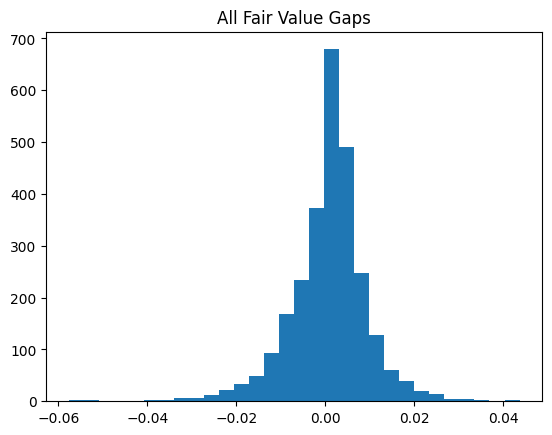

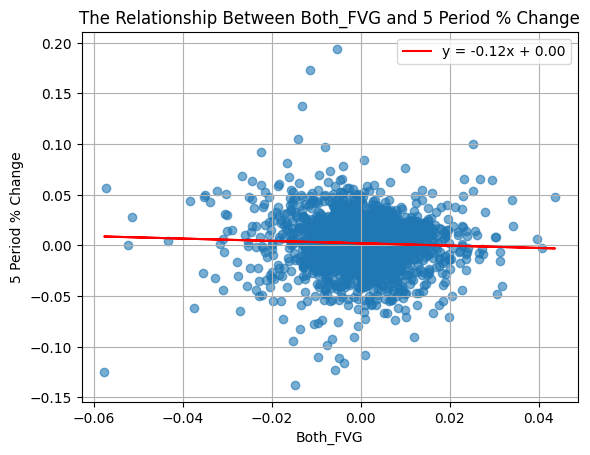

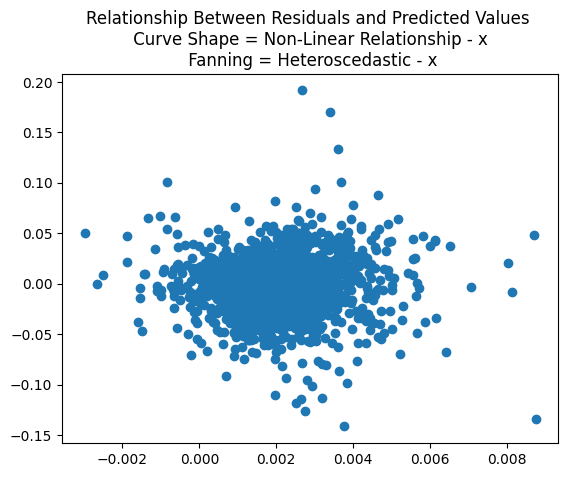

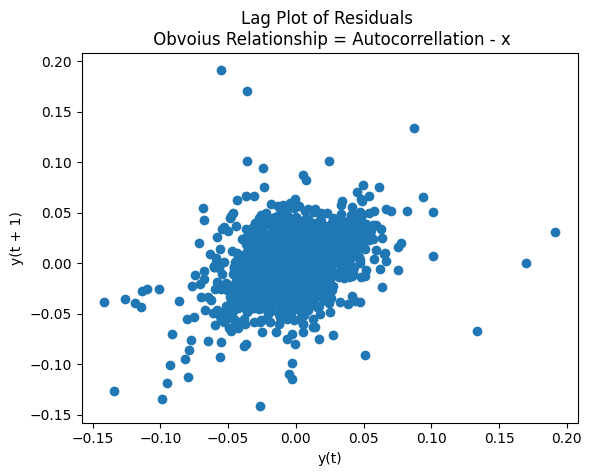

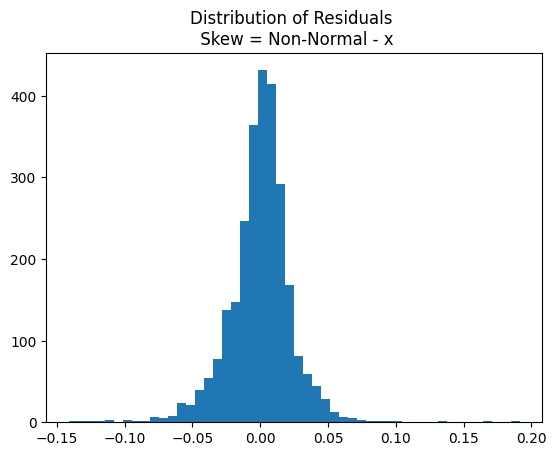

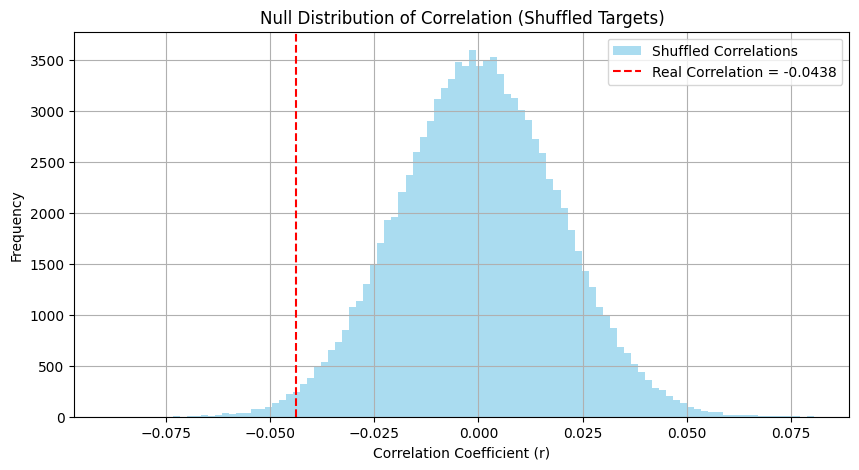

In [ ]:
TICKER = 'SPY'
INTERVAL='1d'

# set period based on interval
if INTERVAL == '1h':
    PERIOD = '730d'
else:
    PERIOD = 'max'

SHIFT = 5
STRATEGY = 'Both_FVG'

# what subsetion of that data are you interested in
LOOKBACK = 10000

def get_data(ticker=TICKER, lookback=LOOKBACK, interval=INTERVAL):

    # get data at interval you want
    df = yf.download(ticker, interval=interval, auto_adjust=False, period=PERIOD)
    df.columns = df.columns.get_level_values(0)

    # reset the index to make plots prettier
    df = df.reset_index(drop=True)

    # only return the subset of data you are interested in
    return df.iloc[-lookback:, :]

# define the target variable (also called dependent variable, or y)
def add_target(df, shift=SHIFT):

    # what is the close price SHIFT days from now?
    df[f'Close + {shift}'] = df['Close'].shift(-shift)

    # what is the change in close price SHIFT days from now?
    df[f'{shift} Period % Change'] = (df[f'Close + {shift}'] - df['Close']) / df['Close']

    return df

def bull_fvg(df):

    df['High_2prev'] = df['High'].shift(2)
    df['Bull_FVG'] = (df['Low'] > df['High_2prev']).astype(int)
    df['Bull_FVG_Val'] = (df['Low'] - df['High_2prev']) * df['Bull_FVG'] / df['Close']

    return df

def bear_fvg(df):

    df['Low_2prev'] = df['Low'].shift(2)
    df['Bear_FVG'] = (df['High'] < df['Low_2prev']).astype(int)
    df['Bear_FVG_Val'] = (df['High'] - df['Low_2prev']) * df['Bear_FVG'] / df['Close']

    return df

def prepare_dataframe_for_regression(df):
    df = df[(df['Bull_FVG'] == 1) | (df['Bear_FVG'] == 1)].copy()
    df['Both_FVG'] = df['Bear_FVG_Val'] + df['Bull_FVG_Val']

    plt.figure()
    plt.hist(df['Both_FVG'], bins=30)
    plt.title('All Fair Value Gaps')

    return df

def generate_regression_output(df, features=f'{STRATEGY}', target=f'{SHIFT} Period % Change'):
    subset = df[[features, target]].dropna()

    X = subset[features]
    y = subset[target]

    X_with_const = sm.add_constant(X)
    model = sm.OLS(y, X_with_const).fit()

    intercept = model.params['const']
    coefficient = model.params[features]
    y_pred = model.predict(X_with_const)

    # Console summary
    print(model.summary())

    # Plot
    plt.figure()
    plt.title(f'The Relationship Between {features} and {target}')
    plt.plot(X, y_pred, color='red', label=f'y = {coefficient:.2f}x + {intercept:.2f}')
    plt.scatter(X, y, alpha=0.6)
    plt.xlabel(f"{features}")
    plt.ylabel(f"{target}")
    plt.legend()
    plt.grid(True)

    return df, intercept, coefficient

def validate_regression_output(df, coef, intercept):

    # information necessary
    df['Predictions'] = coef * df[f'{STRATEGY}'] + intercept
    df['Residuals'] = df[f'{SHIFT} Period % Change'] - df['Predictions']

    # plot for linearity/homoscedasticity
    plt.figure()
    plt.scatter(df['Predictions'], df['Residuals'])
    plt.title('Relationship Between Residuals and Predicted Values \n ' \
        'Curve Shape = Non-Linear Relationship - x \n ' \
        'Fanning = Heteroscedastic - x')

    # plot for autocorrelations
    plt.figure()
    lag_plot(df['Residuals'].dropna())
    plt.title('Lag Plot of Residuals \n Obvoius Relationship = Autocorrellation - x')

    # plot for normality
    plt.figure()
    plt.hist(df['Residuals'], bins=50)
    plt.title('Distribution of Residuals \n Skew = Non-Normal - x')

    return df

def assess_regression_output(df, coef, features=f'{STRATEGY}', target=f'{SHIFT} Period % Change', n=100000):
    subset = df[[features, target]].dropna()
    X = subset[features]
    y = subset[target]

    real_r = np.corrcoef(X, y)[0, 1]
    correlations = []

    for _ in range(n):
        shuffled_y = np.random.permutation(y)
        r = np.corrcoef(X, shuffled_y)[0, 1]
        correlations.append(r)

    # Plot
    plt.figure(figsize=(10, 5))
    plt.hist(correlations, bins=100, alpha=0.7, color='skyblue', label='Shuffled Correlations')
    plt.axvline(real_r, color='red', linestyle='--', label=f'Real Correlation = {real_r:.4f}')
    plt.title('Null Distribution of Correlation (Shuffled Targets)')
    plt.xlabel('Correlation Coefficient (r)')
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(True)

    return df

def main():
    df = get_data()
    df = add_target(df)
    df = bull_fvg(df)
    df = bear_fvg(df)
    df = prepare_dataframe_for_regression(df)
    df, fit_intercept, fit_coefficient = generate_regression_output(df)
    df = validate_regression_output(df, coef=fit_coefficient, intercept=fit_intercept)
    df = assess_regression_output(df, coef=fit_coefficient)

    return df

df = main()
df

### **Explanation of Diagrams**

#### **1. All Fair Value Gaps Histogram**

&nbsp;&nbsp;&nbsp;&nbsp;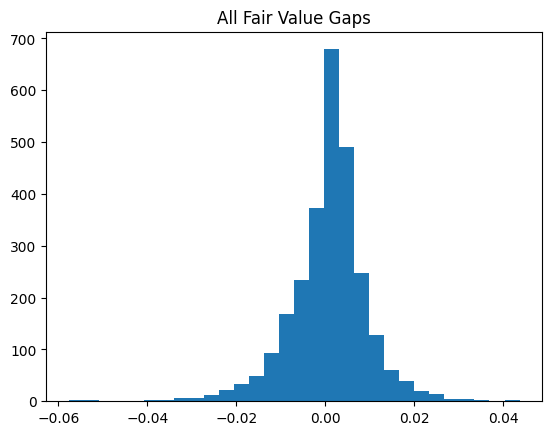

*   **What it represents:** This histogram shows the distribution of the calculated 'Both_FVG' values. 'Both_FVG' is a combined measure of bullish and bearish fair value gaps, normalized by the closing price.
*   **What we could get from it:** It helps us understand the frequency and magnitude of fair value gaps identified in the historical data. A wider spread or specific peaks could indicate common FVG sizes or a balanced presence of bullish and bearish gaps.
*   **How the retail strategy performs:** This diagram provides a high-level overview of the FVG occurrences. If the distribution is centered around zero, it means bullish and bearish gaps are somewhat balanced. If there's a skew, it suggests a dominance of one type of gap. This can inform whether the market tends to create more upward (bullish FVG) or downward (bearish FVG) liquidity voids.

#### **2. The Relationship Between Both_FVG and 5 Period % Change Scatter Plot**

&nbsp;&nbsp;&nbsp;&nbsp;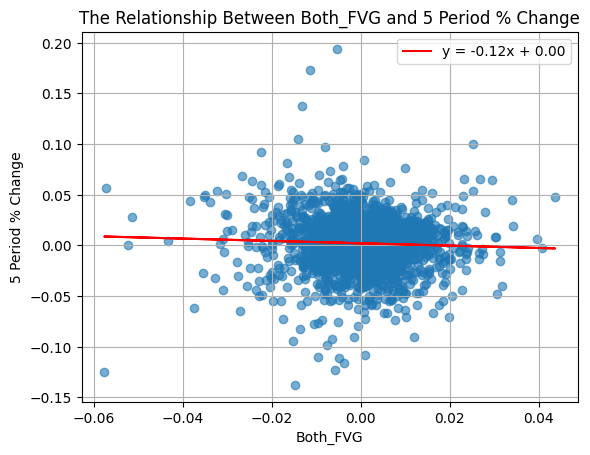

*   **What it represents:** This scatter plot illustrates the relationship between the 'Both_FVG' values (on the X-axis) and the subsequent 5-period percentage change in price (on the Y-axis). A red regression line is fitted to show the linear trend.
*   **What we could get from it:** This plot is crucial for assessing the direct correlation between the FVG and future price movements. The slope and direction of the regression line indicate whether larger FVGs tend to precede positive or negative price changes. The scatter of points around the line shows the variability and strength of this relationship.
*   **How the retail strategy performs:** The retail strategy posits that FVGs are 'liquidity voids' that eventually get 'filled' or cause subsequent price movement. If the regression line shows a clear positive or negative slope and the points are somewhat clustered around it, it would suggest that FVGs have some predictive power for future price changes, validating the core idea of the FVG strategy. The provided output shows a negative coefficient (-0.1157), suggesting that larger `Both_FVG` values are associated with a slight negative `5 Period % Change`. However, the R-squared value of 0.002 indicates a very weak explanatory power.

#### **3. Relationship Between Residuals and Predicted Values Scatter Plot**

&nbsp;&nbsp;&nbsp;&nbsp;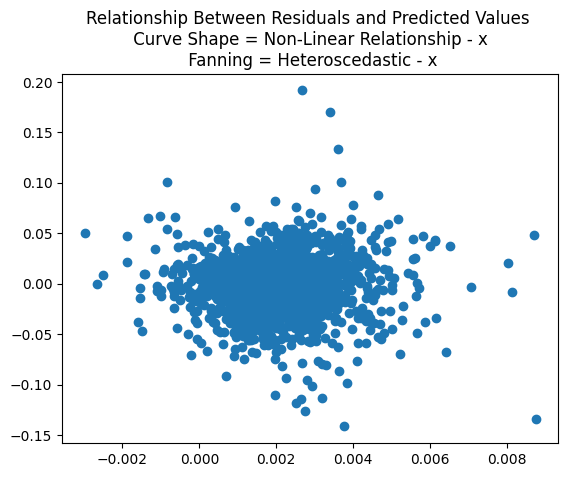

*   **What it represents:** This plot displays the residuals (the differences between actual and predicted price changes) on the Y-axis against the predicted price changes (from the regression model) on the X-axis.
*   **What we could get from it:** This is a diagnostic plot for regression analysis. Ideally, for a linear model, the residuals should be randomly scattered around zero with no discernible pattern (indicating linearity) and a constant spread (indicating homoscedasticity). A 'curve shape' indicates a non-linear relationship, while 'fanning' indicates heteroscedasticity.
*   **How the retail strategy performs:** If there are patterns or 'fanning' in this plot (as indicated by the plot title's 'x'), it suggests that the linear regression model is not the best fit for the data, or that the assumptions of OLS are violated. This implies that the FVG's relationship with future price changes might be more complex than a simple linear one, casting doubt on the direct predictive power of the FVG as modeled.

#### **4. Lag Plot of Residuals**

&nbsp;&nbsp;&nbsp;&nbsp;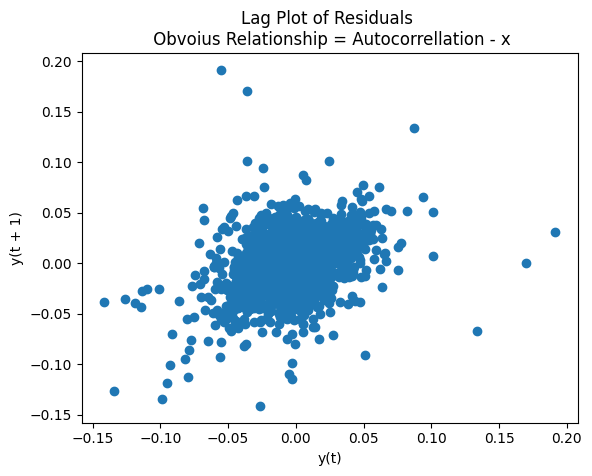

*   **What it represents:** A lag plot shows each residual value against its preceding residual value. Essentially, `Residuals(t)` is plotted against `Residuals(t-1)`.
*   **What we could get from it:** This plot is used to detect autocorrelation in the residuals. If the residuals are truly random and independent (a key assumption of OLS), the lag plot should show a random, amorphous cloud of points. If a discernible pattern emerges (e.g., a linear trend, an oval shape), it indicates autocorrelation.
*   **How the retail strategy performs:** The plot title explicitly states 'Obvious Relationship = Autocorrelation - x', suggesting that there is autocorrelation in the residuals. Autocorrelation means that the error terms of the model are not independent over time, violating an OLS assumption. This further indicates that the FVG model might be missing important time-series dynamics or other relevant variables, reducing confidence in its statistical validity as a standalone predictor.

#### **5. Distribution of Residuals Histogram**

&nbsp;&nbsp;&nbsp;&nbsp;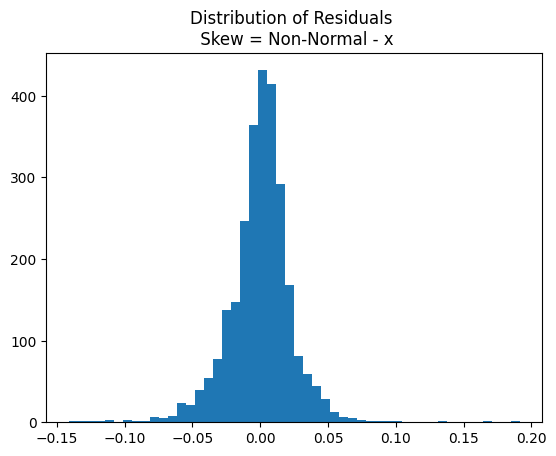

*   **What it represents:** This histogram shows the frequency distribution of the residuals.
*   **What we could get from it:** This plot assesses the normality assumption of residuals. For OLS regression, residuals should ideally follow a normal distribution, appearing as a symmetric bell-shaped curve. Skewness or kurtosis (fat tails or sharp peaks) indicates non-normality.
*   **How the retail strategy performs:** The plot title explicitly states 'Skew = Non-Normal - x', indicating that the residuals are not normally distributed. Non-normal residuals can affect the reliability of statistical inferences (p-values, confidence intervals) derived from the regression model. This again suggests that the basic linear model of FVG's predictive power is flawed or incomplete, and its statistical significance may be questionable.

#### **6. Null Distribution of Correlation (Shuffled Targets) Histogram**

&nbsp;&nbsp;&nbsp;&nbsp;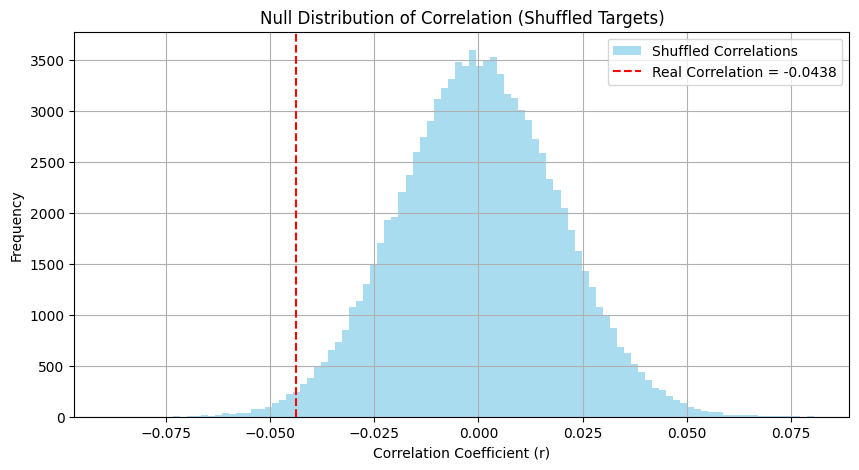

*   **What it represents:** This histogram shows the distribution of correlation coefficients obtained by repeatedly shuffling the target variable ('5 Period % Change') and correlating it with the 'Both_FVG' feature. The 'Real Correlation' (from the unshuffled data) is marked by a vertical red dashed line.
*   **What we could get from it:** This is a permutation test, a robust method to determine if the observed correlation is statistically significant or simply due to chance. The histogram represents the 'null distribution' – what correlations would look like if there were no real relationship. If the 'Real Correlation' falls far outside the bulk of this null distribution (e.g., in the extreme tails), it suggests statistical significance.
*   **How the retail strategy performs:** The provided plot shows the 'Real Correlation' (e.g., -0.0468 in the example output) relative to a null distribution. If the real correlation is very close to the center of the shuffled correlations, it implies that the FVG's observed relationship with future price changes is not statistically significant and could have happened by random chance. This would strongly invalidate the FVG strategy as a source of alpha, as its predictive power would not be distinguishable from random noise. In the context output, the `Real Correlation = -0.0468`, which appears to be within the main body of the shuffled correlations, suggesting a lack of statistical significance for the observed correlation.

### **Acknowledgments & Source**

The algorithmic framework for the Fair Value Gap (FVG) discretization and the permutation testing logic in this module is interpreted from the following open-source repository:
* Original Repository: [Statistical Significance of Fair Value Gaps](https://github.com/n84d/SharpEducation/blob/main/Regression/Reg_FVG.ipynb)
* Author: Sharp Research